In [1]:
library(data.table)
library(dplyr)
library(ComplexHeatmap)

scale_factor = 1.6


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(

In [2]:
# Set directory path
dir_path <- "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/gsMap/Human_Spine/GW17/cauchy_combination/"

# Get all matching .gz files
file_list <- list.files(path = dir_path, 
                       pattern = "^GW17_.*\\.csv\\.gz$",
                       full.names = TRUE)

# Initialize an empty list to store intermediate results
result_list <- list()

# Iterate through all .gz files in the directory
for (file_path in file_list) {
  # Extract trait name
  trait <- gsub("^GW17_(.*?)\\.Cauchy\\.csv\\.gz$", "\\1", basename(file_path))
  
  # Read and process a single file
  df <- fread(cmd = paste("gunzip -c", file_path))
  
  # Compute Cauchy column
  df[, Cauchy := -log10(p_cauchy)]
  
  # Keep only annotation and Cauchy columns
  df <- df[, .(annotation, Cauchy)]
  
  # Rename Cauchy column to trait name
  setnames(df, "Cauchy", trait)
  
  # Append data frame to list
  result_list[[trait]] <- df
}

# Merge all data frames
result_df <- Reduce(function(x, y) {
  merge(x, y, by = "annotation", all = TRUE)
}, result_list)

# Set annotation as row names
result_df <- as.data.frame(result_df)
rownames(result_df) <- result_df$annotation
result_df$annotation <- NULL

# View results
result_df

,AD,AD2,ADHD,AHD,ALS,AN,ANX,AR,ASD,ATM,⋯,Insomnia,IQ,MDD,MS,Neuroticism,OCD,Parasomnia,PTSD,SCZ,SPA
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Cavity,0.35041297,0.1756431,2.3633053,0.02971523,0.6244214,0.03475616,1.11492663,0.6109258,1.0087113,0.110420842,⋯,1.1839850,1.100516,0.79891298,0.004963566,1.5887646,0.9167604,0.4472194,1.834430,2.015240,0.02130237
Dorsal_Horn,0.37492442,0.3067691,4.1549358,0.07283571,1.2299907,0.47778703,0.47795633,0.8758549,1.7688420,0.660743312,⋯,0.8611284,3.444211,3.35667238,0.015649134,4.9282921,1.5385864,0.5736810,4.990616,4.538335,0.05101522
Early_Horn/Lateral_Horn,0.26865296,0.1255890,0.3979028,0.82996977,0.7952908,0.83317193,0.05798453,0.4368222,0.9161348,0.194785675,⋯,0.6483407,1.612256,1.49525535,0.104649432,1.5993921,0.6411331,0.3276159,1.957855,2.628827,0.07970168
Early_White_Matter,0.67919392,0.9381285,1.6411962,0.47689011,0.9724327,0.05906234,0.27067080,0.6119305,0.9448759,0.200536956,⋯,0.9278749,1.478916,1.13261559,0.035797289,1.9548979,0.5207576,0.6520909,2.180386,1.976079,0.11441842
Intermediate_Gray,1.14932029,0.7861252,2.9585101,1.02606583,1.1120382,0.23194574,0.65950794,0.7838166,1.4004259,0.275663131,⋯,0.7805819,3.215608,2.28004162,0.021725769,4.0369236,0.8493751,0.3588175,3.417342,3.906025,0.04947901
MN_Horn,1.02688295,1.2708482,1.6667740,0.83459620,0.9848481,0.04272907,0.19016723,0.7670563,1.0017095,0.340147825,⋯,0.9572762,2.151208,1.37946302,0.027363059,2.7818300,0.7357352,0.5801561,2.388529,2.707639,0.01395186
Meninge,1.80232029,0.8488942,1.8825620,0.02315903,1.0566632,0.02713600,0.08136386,0.1122183,1.4051234,0.066023349,⋯,0.8667939,0.474538,0.04354766,1.118139877,0.8806623,0.3598948,0.7685313,1.009789,1.500152,0.02552098
VZ,1.50142930,0.9680014,2.8147322,0.94518528,1.0589400,0.00730076,0.41848721,0.7158073,0.6864947,0.003376845,⋯,0.9627712,1.863980,1.26969850,0.005403361,1.8531230,0.8985143,0.6615021,2.636289,2.765661,0.04687281
Ventral_Horn,0.06553703,0.2202550,3.2096042,0.53418958,0.9955658,0.60582184,0.27775624,0.7060753,0.9213000,0.419016259,⋯,0.8304868,2.395577,1.98710263,0.016572325,3.1415490,1.3133888,0.3059361,2.878672,3.055737,0.07539117


In [3]:
dim(result_df)

[1] 10 27

In [4]:
mat = as.matrix(result_df)
niche = c("Dorsal_Horn",
    "Intermediate_Gray",
    "Ventral_Horn",
    "Early_Horn/Lateral_Horn",
    "MN_Horn",
    "Early_White_Matter",
    "White_Matter",
    "VZ",
    "Meninge",
    "Cavity")
mat = mat[niche,]

In [5]:
name_region = rownames(mat)
TissueLabel = rowAnnotation(
  tissue = anno_mark(at = seq(1,nrow(result_df)),
                    labels = name_region,which = 'row',side='left',
                    labels_rot = 0,padding = 0.1,labels_gp = gpar(fontsize = 13*scale_factor)
                   )
)

In [6]:
# Set The column label (show traits)
traitLbel = columnAnnotation(
  trait = anno_mark(at = seq(1,ncol(mat)),
                    labels = colnames(mat),which = 'column',side='bottom',
                    labels_rot = 45,padding = 0.1,labels_gp = gpar(fontsize = 13*scale_factor)
                   )
)

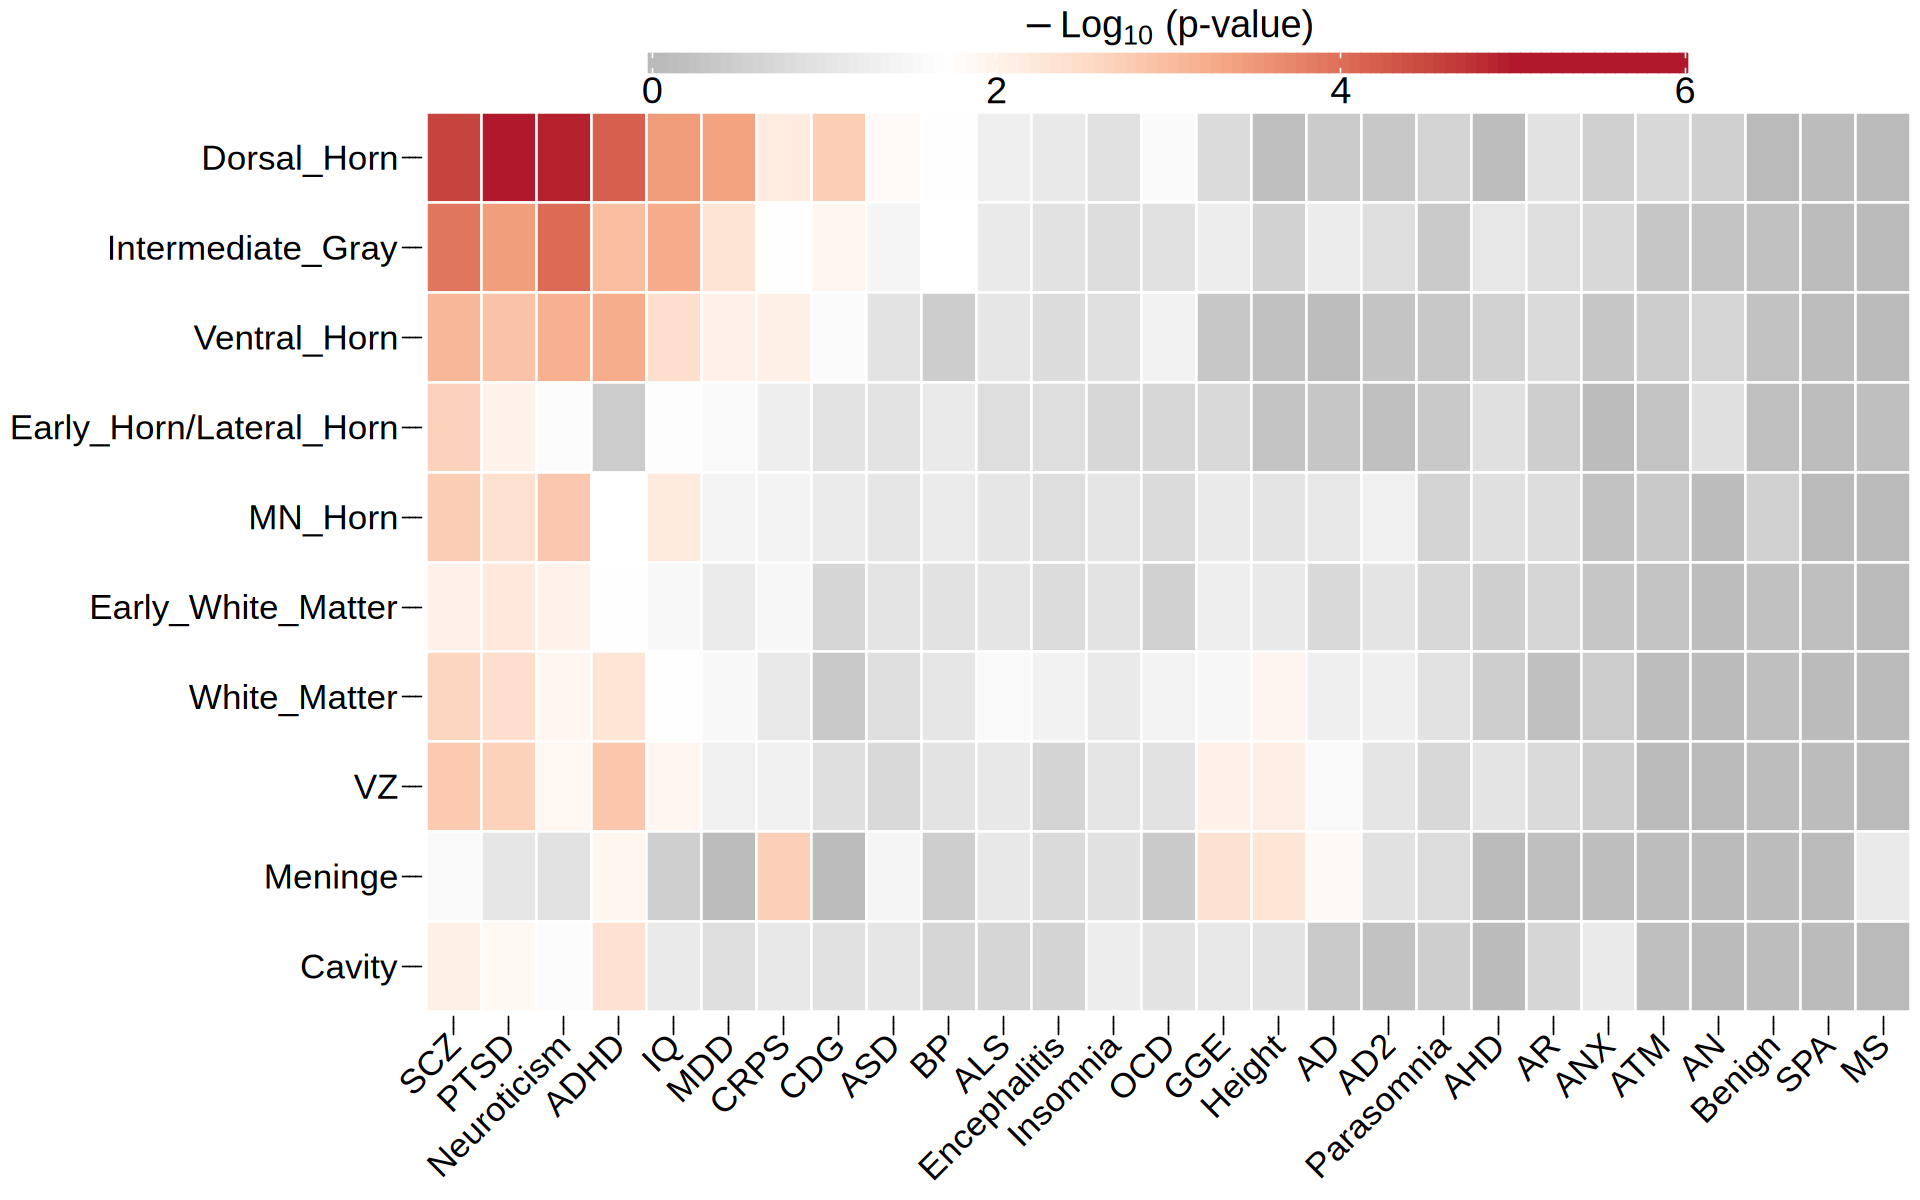

In [7]:
p_cauchy = rev(c("#b2182b","#d6604d","#f4a582","#fddbc7","#ffffff","#e0e0e0","#bababa"))

hmap = Heatmap(mat,cluster_columns = T,cluster_rows = F,
               show_row_names = F,show_column_names = F,show_column_dend = FALSE,row_dend_side = 'left',
        rect_gp = gpar(col = "white", lwd = 1.5),
        heatmap_legend_param = list(
          title = expression(-Log[10] ~ "(p-value)"),
          direction = "horizontal",  
          legend_width = unit(22, "cm"),size=14*scale_factor,
          title_gp = gpar(fontsize = 14*scale_factor),
          labels_gp = gpar(fontsize = 14*scale_factor), 
          title_position = "topcenter"),
        left_annotation = TissueLabel,     
        bottom_annotation = traitLbel,
        col = p_cauchy
      )

options(repr.plot.width = 16,repr.plot.height = 10)
draw(hmap,heatmap_legend_side = 'top')
figb = grid.grabExpr(draw(hmap,heatmap_legend_side = 'top'))

In [8]:
pdf("./figure/heatmap.pdf", width=16, height=8)  # Open PDF device and set width/height
draw(hmap, heatmap_legend_side='top')    # Draw heatmap
dev.off()                                # Close PDF device

pdf 
  2